# Lab 10 — kNN Classification of Leaves



In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
RNG = 42  # fixed seed so the report is reproducible
np.random.seed(RNG)

In [22]:
df = pd.read_csv("Leaf_Data.csv")

# the original CSV has a trailing space in '# betas '; rename for sanity
df = df.rename(columns={c: c.strip() for c in df.columns})

print("Raw shape:", df.shape)
df.head()

Raw shape: (78, 6)


,Tipo,# betas,Largo(cm),Ancho(cm),theta(°),L(45°)(cm)
0,palmeada,1,5.5,3.0,65.0,2.5
1,lanceolada,1,8.0,2.0,25.0,0.0
2,palmeada,1,7.5,4.5,35.0,0.0
3,palmeada,1,9.0,3.5,50.0,2.0
4,dentada,5,7.0,8.5,135.0,7.0


In [23]:
# class distribution before cleaning
print("Tipo value counts (including NaN):")
print(df["Tipo"].value_counts(dropna=False))
print("\nMissing values per column:")
print(df.isnull().sum())

Tipo value counts (including NaN):
Tipo
lanceolada    36
palmeada      27
dentada       15
Name: count, dtype: int64

Missing values per column:
Tipo          0
# betas       0
Largo(cm)     0
Ancho(cm)     0
theta(°)      0
L(45°)(cm)    0
dtype: int64


In [24]:
# one row has no label (row 13 in the original CSV) — drop it.
df = df.dropna(subset=["Tipo"]).reset_index(drop=True)

# the 'Estrella' column is just an ID, not a feature
FEATURES = ["# betas", "Largo(cm)", "Ancho(cm)", "theta(°)", "L(45°)(cm)"]
TARGET   = "Tipo"

print("Clean shape :", df.shape)
print("Class counts:")
print(df[TARGET].value_counts())

Clean shape : (78, 6)
Class counts:
Tipo
lanceolada    36
palmeada      27
dentada       15
Name: count, dtype: int64


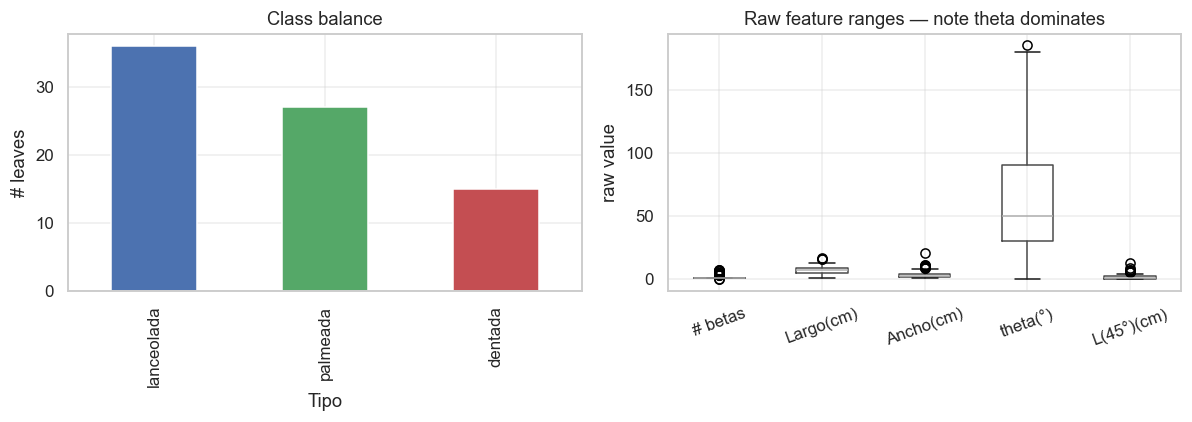

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# class balance
df[TARGET].value_counts().plot.bar(ax=axes[0],
                                   color=["#4C72B0", "#55A868", "#C44E52"])
axes[0].set_title("Class balance")
axes[0].set_ylabel("# leaves")
axes[0].set_xlabel("Tipo")

# feature-scale comparison (this is why we must standardize!)
df[FEATURES].boxplot(ax=axes[1], rot=20)
axes[1].set_title("Raw feature ranges — note theta dominates")
axes[1].set_ylabel("raw value")

plt.tight_layout()
plt.show()

**Observation.** `theta(°)` reaches values up to ~250 while `# betas` is between 1 and 5. Euclidean distance computed on these raw values is almost entirely dictated by `theta`. Standardizing each feature to zero mean / unit variance is essential for kNN to use all features equitably.

In [26]:
"""Publication-quality figures for the Lab 10 leaf-classification report.

Generates three PDF figures sized for a two-column article (linewidth ~3.3 in,
textwidth ~6.9 in) plus PNG previews.
"""
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ---------- styling -------------------------------------------------------
plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        9,
    "axes.titlesize":   9,
    "axes.labelsize":   9,
    "legend.fontsize":  8,
    "xtick.labelsize":  8,
    "ytick.labelsize":  8,
    "axes.linewidth":   0.6,
    "axes.grid":        True,
    "grid.linewidth":   0.4,
    "grid.alpha":       0.35,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
    "pdf.fonttype":     42,  # editable text in vector PDF
    "ps.fonttype":      42,
})

CLASS_PALETTE = {
    "dentada":    "#4C72B0",
    "lanceolada": "#DD8452",
    "palmeada":   "#55A868",
}
CLASS_ORDER = ["dentada", "lanceolada", "palmeada"]

# ---------- data ----------------------------------------------------------
df = pd.read_csv("Leaf_Data.csv")
df = df.rename(columns={c: c.strip() for c in df.columns})
df = df.dropna(subset=["Tipo"]).reset_index(drop=True)

FEATURES = ["# betas", "Largo(cm)", "Ancho(cm)", "theta(°)", "L(45°)(cm)"]
PRETTY = {
    "# betas":    r"$s$ (stems)",
    "Largo(cm)":  r"$l_{\max}$ (cm)",
    "Ancho(cm)":  r"$a_{\max}$ (cm)",
    "theta(°)":   r"$\theta_{\mathrm{base}}$ ($^\circ$)",
    "L(45°)(cm)": r"$l_\theta$ (cm)",
}

scaler = StandardScaler().fit(df[FEATURES])
X_raw = df[FEATURES].to_numpy()
X_std = scaler.transform(df[FEATURES])
y_str = df["Tipo"].astype(str).to_numpy()

# print the actual scaling parameters so the user can quote them
print("Standardization parameters (fit on full dataset, for EDA only):")
print(pd.DataFrame({
    "feature": FEATURES,
    "mu":      np.round(scaler.mean_, 3),
    "sigma":   np.round(np.sqrt(scaler.var_), 3),
}).to_string(index=False))

Path("figs").mkdir(exist_ok=True)

# ---------- Figure 1: per-feature before/after standardization -----------
# layout: 2 rows (raw / standardized) x 5 columns (one per feature)
# we use KDE curves instead of stacked histograms — clearer class structure
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(2, 5, figsize=(6.9, 3.0))

for col, feat in enumerate(FEATURES):
    raw_vals = X_raw[:, col]
    std_vals = X_std[:, col]

    # grids for KDE evaluation
    r_lo, r_hi = raw_vals.min(), raw_vals.max()
    r_pad = 0.05 * (r_hi - r_lo + 1e-9)
    raw_grid = np.linspace(r_lo - r_pad, r_hi + r_pad, 300)
    std_grid = np.linspace(std_vals.min() - 0.3, std_vals.max() + 0.3, 300)

    for cls in CLASS_ORDER:
        mask = (y_str == cls)
        if mask.sum() < 2:
            continue
        try:
            kde_r = gaussian_kde(raw_vals[mask], bw_method=0.4)
            kde_s = gaussian_kde(std_vals[mask], bw_method=0.4)
            axes[0, col].fill_between(raw_grid, kde_r(raw_grid),
                                      color=CLASS_PALETTE[cls], alpha=0.35,
                                      linewidth=0)
            axes[0, col].plot(raw_grid, kde_r(raw_grid),
                              color=CLASS_PALETTE[cls], lw=1.0)
            axes[1, col].fill_between(std_grid, kde_s(std_grid),
                                      color=CLASS_PALETTE[cls], alpha=0.35,
                                      linewidth=0)
            axes[1, col].plot(std_grid, kde_s(std_grid),
                              color=CLASS_PALETTE[cls], lw=1.0)
        except np.linalg.LinAlgError:
            # constant values within a class (no variance) — fall back to a tick
            axes[0, col].axvline(raw_vals[mask][0],
                                 color=CLASS_PALETTE[cls], lw=1.0, alpha=0.7)
            axes[1, col].axvline(std_vals[mask][0],
                                 color=CLASS_PALETTE[cls], lw=1.0, alpha=0.7)

    axes[0, col].set_title(PRETTY[feat])
    axes[1, col].set_xlabel("z-score")
    axes[1, col].axvline(0, color="k", lw=0.5, ls="--", alpha=0.6)
    axes[0, col].set_yticks([])
    axes[1, col].set_yticks([])

axes[0, 0].set_ylabel("density\n(raw)")
axes[1, 0].set_ylabel("density\n(standardized)")

# single legend at top
handles = [plt.Rectangle((0, 0), 1, 1, color=CLASS_PALETTE[c], alpha=0.6)
           for c in CLASS_ORDER]
fig.legend(handles, CLASS_ORDER, loc="upper center",
           bbox_to_anchor=(0.5, 1.04), ncol=3, frameon=False)

plt.tight_layout()
fig.savefig("figs/feature_standardization.pdf")
fig.savefig("figs/feature_standardization.png")
plt.close(fig)
print("wrote figs/feature_standardization.{pdf,png}")

# ---------- Figure 2: feature-range comparison (boxplot, log-y) ----------
# this is the "why we need scaling" plot — one panel, very compact
fig, axes = plt.subplots(1, 2, figsize=(6.9, 2.6))

# left: raw, log-scale to see the wildly different ranges in one frame
bp = axes[0].boxplot([X_raw[:, i] for i in range(len(FEATURES))],
                     labels=[PRETTY[f] for f in FEATURES],
                     patch_artist=True, widths=0.55)
for patch in bp["boxes"]:
    patch.set_facecolor("#CCCCCC")
    patch.set_edgecolor("0.2")
axes[0].set_yscale("symlog", linthresh=1)
axes[0].set_ylabel("raw value (symlog)")
axes[0].set_title("Before standardization")
axes[0].tick_params(axis="x", rotation=20)

# right: standardized, linear scale
bp = axes[1].boxplot([X_std[:, i] for i in range(len(FEATURES))],
                     labels=[PRETTY[f] for f in FEATURES],
                     patch_artist=True, widths=0.55)
for patch in bp["boxes"]:
    patch.set_facecolor("#CCCCCC")
    patch.set_edgecolor("0.2")
axes[1].axhline(0, color="k", lw=0.5, ls="--", alpha=0.6)
axes[1].set_ylabel("z-score")
axes[1].set_title("After standardization")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
fig.savefig("figs/feature_ranges.pdf")
fig.savefig("figs/feature_ranges.png")
plt.close(fig)
print("wrote figs/feature_ranges.{pdf,png}")

# ---------- Figure 3: streamlined pairplot of standardized features ------
# only the most informative pairs for a two-column article
PAIRS = [
    ("Largo(cm)",  "Ancho(cm)"),
    ("Largo(cm)",  "theta(°)"),
    ("Ancho(cm)",  "L(45°)(cm)"),
    ("theta(°)",   "# betas"),
]

# labels without units, since standardized values are dimensionless z-scores
SYMBOL = {
    "# betas":    r"$s$",
    "Largo(cm)":  r"$l_{\max}$",
    "Ancho(cm)":  r"$a_{\max}$",
    "theta(°)":   r"$\theta_{\mathrm{base}}$",
    "L(45°)(cm)": r"$l_\theta$",
}

fig, axes = plt.subplots(1, 4, figsize=(6.9, 2.15))

for ax, (fx, fy) in zip(axes, PAIRS):
    ix = FEATURES.index(fx)
    iy = FEATURES.index(fy)
    for cls in CLASS_ORDER:
        m = (y_str == cls)
        ax.scatter(X_std[m, ix], X_std[m, iy],
                   c=CLASS_PALETTE[cls], s=14, alpha=0.75,
                   edgecolor="white", linewidth=0.3, label=cls)
    ax.set_xlabel(f"{SYMBOL[fx]}  (z-score)")
    ax.set_ylabel(f"{SYMBOL[fy]}  (z-score)")
    ax.axhline(0, color="k", lw=0.4, ls=":", alpha=0.5)
    ax.axvline(0, color="k", lw=0.4, ls=":", alpha=0.5)

handles = [plt.Line2D([0], [0], marker="o", color="w",
                      markerfacecolor=CLASS_PALETTE[c],
                      markeredgecolor="white", markersize=6, label=c)
           for c in CLASS_ORDER]
fig.legend(handles=handles, loc="upper center",
           bbox_to_anchor=(0.5, 1.07), ncol=3, frameon=False)

plt.tight_layout()
fig.savefig("figs/pairs_standardized.pdf")
fig.savefig("figs/pairs_standardized.png")
plt.close(fig)
print("wrote figs/pairs_standardized.{pdf,png}")

Standardization parameters (fit on full dataset, for EDA only):
   feature     mu  sigma
   # betas  1.821  1.745
 Largo(cm)  6.672  3.398
 Ancho(cm)  3.917  3.527
  theta(°) 60.071 39.576
L(45°)(cm)  1.758  2.482
wrote figs/feature_standardization.{pdf,png}


C:\Users\Bruno Abello\AppData\Local\Temp\ipykernel_3240\2429572076.py:134: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot([X_raw[:, i] for i in range(len(FEATURES))],
C:\Users\Bruno Abello\AppData\Local\Temp\ipykernel_3240\2429572076.py:146: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([X_std[:, i] for i in range(len(FEATURES))],


wrote figs/feature_ranges.{pdf,png}
wrote figs/pairs_standardized.{pdf,png}


In [27]:
def strict_predict(knn, X, tau=0.6, other_label="other"):
    # kNN prediction with an 'other' bucket when no class clears tau
    proba = knn.predict_proba(X)
    classes = knn.classes_
    best_idx = proba.argmax(axis=1)
    best_p   = proba.max(axis=1)
    out = np.where(best_p >= tau, classes[best_idx], other_label)
    return out

def run_split(df, feats, target, val_size, ks=range(1, 16),
              tau=0.6, seed=RNG):
    # one full experiment: split -> scale -> sweep k -> return diagnostics
    # cast to plain numpy: newer pandas (Py3.14) may return pyarrow-backed
    # arrays that train_test_split's stratify cannot index.
    X = np.asarray(df[feats].values, dtype=float)
    y = np.asarray(df[target].astype(str).tolist(), dtype=object)

    X_tr, X_va, y_tr, y_va = train_test_split(
        X, y, test_size=val_size, random_state=seed, stratify=y)

    scaler = StandardScaler().fit(X_tr)
    X_tr_s = scaler.transform(X_tr)
    X_va_s = scaler.transform(X_va)

    accs = []
    for k in ks:
        knn = KNeighborsClassifier(n_neighbors=k, p=2, metric="minkowski")
        knn.fit(X_tr_s, y_tr)
        accs.append(accuracy_score(y_va, knn.predict(X_va_s)))
    accs = np.array(accs)
    best_k = list(ks)[int(accs.argmax())]

    knn = KNeighborsClassifier(n_neighbors=best_k, p=2, metric="minkowski")
    knn.fit(X_tr_s, y_tr)

    y_loose  = knn.predict(X_va_s)
    y_strict = strict_predict(knn, X_va_s, tau=tau)

    return {
        "val_size": val_size,
        "n_train": len(y_tr), "n_val": len(y_va),
        "ks": list(ks), "accs": accs, "best_k": best_k,
        "knn": knn, "scaler": scaler,
        "y_va": y_va, "y_loose": y_loose, "y_strict": y_strict,
        "tau": tau,
    }

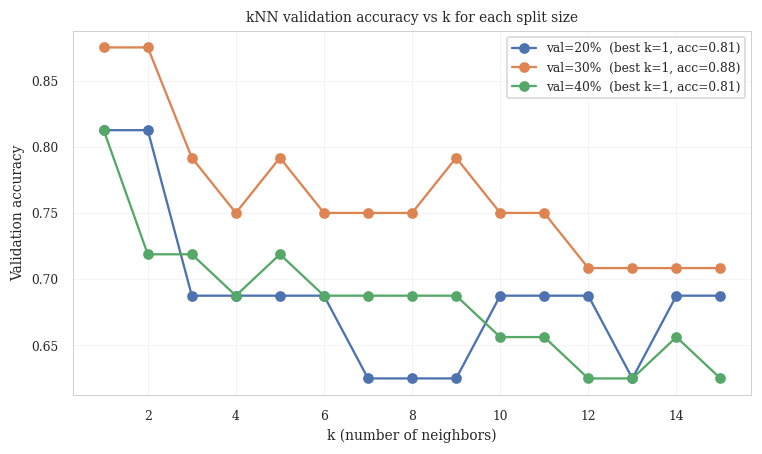

In [28]:
VAL_SIZES = [0.20, 0.30, 0.40]
results = {v: run_split(df, FEATURES, TARGET, v) for v in VAL_SIZES}

fig, ax = plt.subplots(figsize=(7, 4.2))
for v, r in results.items():
    ax.plot(r["ks"], r["accs"], marker="o",
            label=f"val={int(v*100)}%  (best k={r['best_k']}, "
                  f"acc={r['accs'].max():.2f})")
ax.set_xlabel("k (number of neighbors)")
ax.set_ylabel("Validation accuracy")
ax.set_title("kNN validation accuracy vs k for each split size")
ax.legend()
plt.tight_layout()
plt.show()

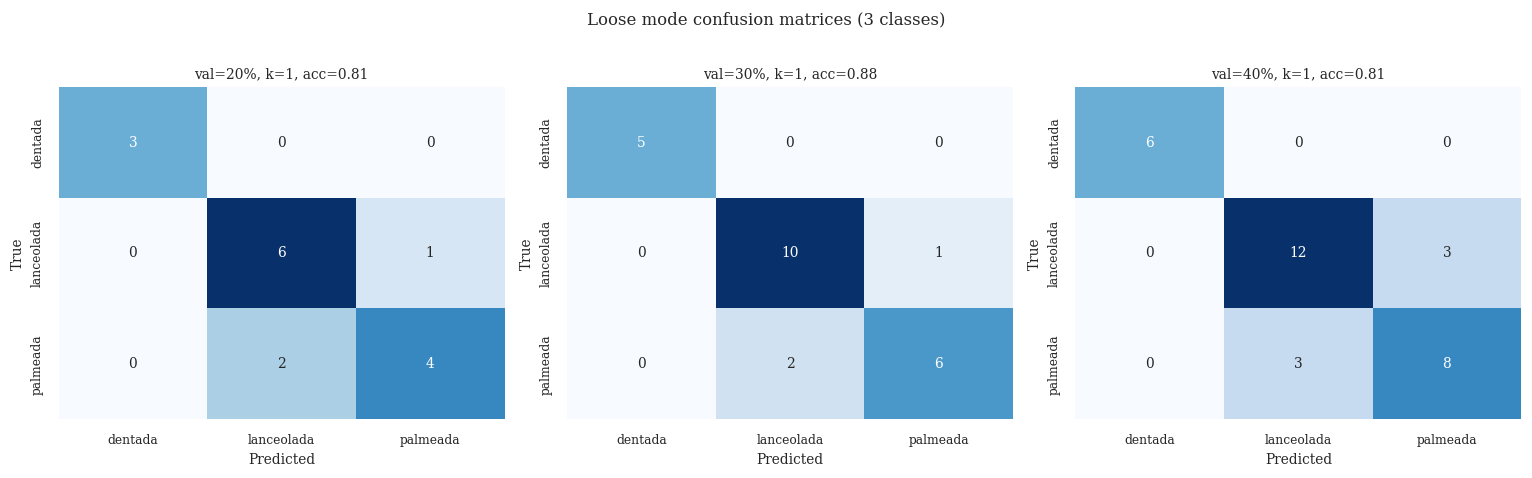

In [29]:
classes_3 = sorted(df[TARGET].unique())  # ['dentada', 'lanceolada', 'palmeada']

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (v, r) in zip(axes, results.items()):
    cm = confusion_matrix(r["y_va"], r["y_loose"], labels=classes_3)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes_3, yticklabels=classes_3, ax=ax,
                cbar=False)
    acc = accuracy_score(r["y_va"], r["y_loose"])
    ax.set_title(f"val={int(v*100)}%, k={r['best_k']}, acc={acc:.2f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.suptitle("Loose mode confusion matrices (3 classes)", y=1.02)
plt.tight_layout()
plt.show()

In [30]:
for v, r in results.items():
    print(f"\n--- Validation = {int(v*100)}%  (k={r['best_k']}) ---")
    print(classification_report(r["y_va"], r["y_loose"],
                                labels=classes_3, zero_division=0))


--- Validation = 20%  (k=1) ---
              precision    recall  f1-score   support

     dentada       1.00      1.00      1.00         3
  lanceolada       0.75      0.86      0.80         7
    palmeada       0.80      0.67      0.73         6

    accuracy                           0.81        16
   macro avg       0.85      0.84      0.84        16
weighted avg       0.82      0.81      0.81        16


--- Validation = 30%  (k=1) ---
              precision    recall  f1-score   support

     dentada       1.00      1.00      1.00         5
  lanceolada       0.83      0.91      0.87        11
    palmeada       0.86      0.75      0.80         8

    accuracy                           0.88        24
   macro avg       0.90      0.89      0.89        24
weighted avg       0.88      0.88      0.87        24


--- Validation = 40%  (k=1) ---
              precision    recall  f1-score   support

     dentada       1.00      1.00      1.00         6
  lanceolada       0.80      0